In [14]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
import numpy as np

from featuregraph.accumulation.accumulations import add_accumulation_signal

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python: /workspaces/featuregraph/.venv/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [15]:
bidmc = fg.datasets.bidmc(
    subject=1,
)

In [16]:
bidmc = fg.oscillation.waves.add_wave_primitives(bidmc, ['respiration'])
bidmc = fg.oscillation.waves.add_wave_id(bidmc, ['respiration'], 'subject')
bidmc = fg.oscillation.waves.add_wave_features(bidmc, ['respiration'], 'respiration_wave_id')

In [17]:
bidmc['respiration_wave_id']

0          0
1          0
2          0
3          0
4          0
        ... 
59996    554
59997    554
59998    554
59999    554
60000    554
Name: respiration_wave_id, Length: 60001, dtype: int64

In [18]:
from featuregraph.utils.plot import plot

In [19]:
bidmc.columns.tolist()

['time',
 'respiration',
 'ppg',
 'ecg_v',
 'ecg_avr',
 'ecg_ii',
 'subject',
 'respiration_rising',
 'respiration_falling',
 'enter_respiration_rising',
 'exit_respiration_rising',
 'respiration_peak_index',
 'respiration_trough_index',
 'respiration_wave_id',
 'respiration_rising_time',
 'respiration_falling_time',
 'respiration_amplitude',
 'respiration_duration']

In [23]:
baseline = (
    bidmc.groupby('respiration_wave_id')['respiration']
         .transform('min')
)

bidmc['respiration_above_baseline'] = (
    bidmc['respiration'] - baseline
)

bidmc['auc_above_baseline'] = (
    bidmc.groupby('respiration_wave_id')
         ['respiration_above_baseline']
         .cumsum()
)


bidmc['auc_at_peak'] = np.where(bidmc['exit_respiration_rising'] == 1, bidmc['auc_above_baseline'], 0)
bidmc['is_auc_above_baseline'] = bidmc['auc_above_baseline'] > 0
bidmc['before_peak'] = bidmc.groupby('respiration_wave_id')['exit_respiration_rising'].cumsum() == 0
bidmc['after_peak'] = bidmc.groupby('respiration_wave_id')['exit_respiration_rising'].cumsum() > 0
bidmc['accumulation_before_peak'] = np.where(bidmc['before_peak'] == 1, bidmc['respiration_above_baseline'], 0)
bidmc['accumulation_from_peak'] = np.where(bidmc['after_peak'] == 1, bidmc['respiration_above_baseline'], 0)
bidmc['wave_index'] = bidmc.groupby('respiration_wave_id').transform('cumcount')
bidmc['weighted_acc'] = bidmc['wave_index'] * bidmc['respiration_above_baseline']
bidmc['total_auc'] = bidmc.groupby('respiration_wave_id')['respiration_above_baseline'].transform('sum')
bidmc['reached_half_acc'] = (
    bidmc['auc_above_baseline'] >= bidmc['half_auc']
)
bidmc['half_auc'] = bidmc['total_auc'] * .5
half_acc_time = (
    bidmc.loc[bidmc['reached_half_acc']]
    .groupby('respiration_wave_id')['wave_index']
    .first()
)

bidmc['half_acc_time'] = (
    bidmc['respiration_wave_id'].map(half_acc_time)
)

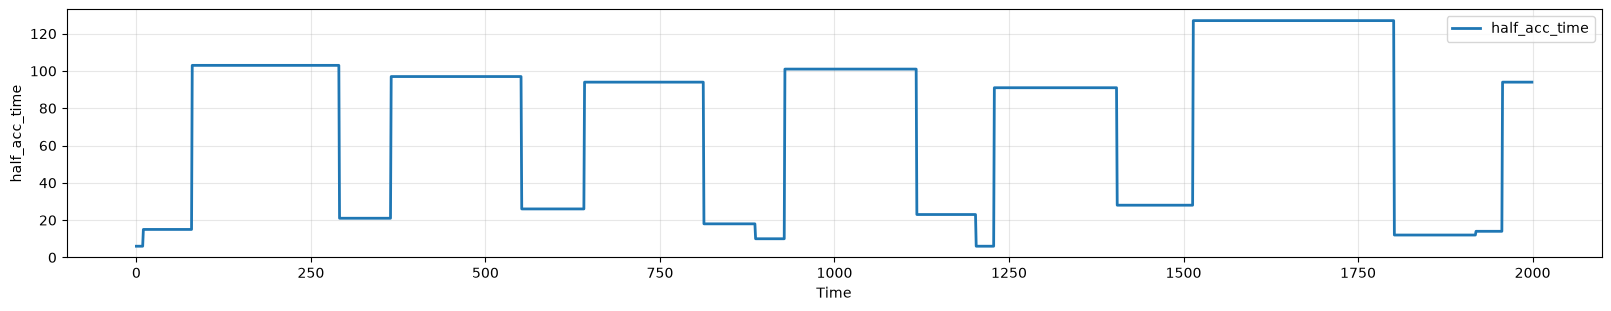

In [24]:
bidmc['diff'] = bidmc['respiration'].diff()
fig, axes = plot(bidmc[:2000],[
                               ['half_acc_time']
])

In [25]:
summarydf = bidmc.groupby('respiration_wave_id').agg(
    total_auc=('auc_above_baseline', 'max'),
    accumulation_before_peak=('accumulation_before_peak', 'sum'),
    accumulation_from_peak=('accumulation_from_peak', 'sum'),
    auc_at_peak=('auc_at_peak', 'max'),
    time_to_max_auc=('is_auc_above_baseline', 'sum'),
    first_moment=('weighted_acc', 'sum'),
    half_acc_time=('half_acc_time', 'first')
    )

In [26]:
summarydf['accumulation_rate'] = summarydf['total_auc'] / summarydf['time_to_max_auc']
summarydf['accumulation_symmetry'] = 1 - ((summarydf['accumulation_before_peak'] - summarydf['accumulation_from_peak']).abs() / \
                                     (summarydf['accumulation_before_peak'] + summarydf['accumulation_from_peak']))
summarydf['centroid_time'] = summarydf['first_moment'] / summarydf['total_auc']
summarydf.reset_index()

,respiration_wave_id,total_auc,accumulation_before_peak,accumulation_from_peak,auc_at_peak,time_to_max_auc,first_moment,half_acc_time,accumulation_rate,accumulation_symmetry,centroid_time
0,0,0.093840,0.093840,0.000000,0.000000,9,0.562040,6,0.010427,0.000000,5.989344
1,1,9.866038,1.393938,8.472100,1.737045,70,184.274276,15,0.140943,0.282573,18.677637
2,2,121.809414,44.773236,77.036178,45.742933,210,12832.093949,103,0.580045,0.735136,105.345667
3,3,9.390079,1.906150,7.483929,2.138800,74,226.192528,21,0.126893,0.405992,24.088458
4,4,107.700804,48.562984,59.137820,49.525838,186,10428.538106,97,0.579037,0.901813,96.828786
...,...,...,...,...,...,...,...,...,...,...,...
550,550,11.942353,8.030342,3.912011,8.267878,95,388.357101,33,0.125709,0.655149,32.519312
551,551,3.753673,2.442815,1.310858,2.547406,56,125.080453,33,0.067030,0.698440,33.322150
552,552,98.348120,54.010800,44.337320,54.841690,201,10529.251090,110,0.489294,0.901640,107.061031
553,553,11.359690,6.677400,4.682290,6.927640,85,296.041250,25,0.133643,0.824369,26.060680


<!-- Possible feature	Meaning
total_auc	Total accumulated quantity
accumulation_rate	Average accumulation per unit time
peak_accumulation_rate	Maximum instantaneous contribution
accumulation_before_peak	Quantity accumulated before peak
accumulation_after_peak	Quantity accumulated after peak
accumulation_symmetry	Fraction accumulated before vs. after peak
normalized_auc	AUC normalized by duration or amplitude
accumulation_efficiency	AUC relative to theoretical maximum
centroid_time	Center of mass of accumulated quantity
half_accumulation_time	Time when 50% of total accumulation has occurred -->

In [ ]:
# Possible feature	Meaning
# total_auc	Total accumulated quantity
# accumulation_rate	Average accumulation per unit time
# peak_accumulation_rate	Maximum instantaneous contribution
# accumulation_before_peak	Quantity accumulated before peak
# accumulation_after_peak	Quantity accumulated after peak
# accumulation_symmetry	Fraction accumulated before vs. after peak
# normalized_auc	AUC normalized by duration or amplitude
# accumulation_efficiency	AUC relative to theoretical maximum
# centroid_time	Center of mass of accumulated quantity
# half_accumulation_time	Time when 50% of total accumulation has occurred

In [21]:
bidmc

,time,respiration,ppg,ecg_v,ecg_avr,ecg_ii,subject,respiration_rising,respiration_falling,enter_respiration_rising,...,respiration_peak_index,respiration_trough_index,respiration_wave_id,respiration_rising_time,respiration_falling_time,respiration_amplitude,respiration_duration,respiration_accumulation_threshold,respiration_accumulation_contribution,respiration_accumulation
0,0.000,0.35386,0.43597,0.52549,0.30392,0.72549,1,False,False,False,...,NaN,NaN,0,0,0,0.00733,0,0.35386,0.00000,0.00000
1,0.008,0.35679,0.43206,0.51961,0.33529,0.67059,1,False,False,False,...,NaN,NaN,0,0,0,0.00733,0,0.35386,0.00293,0.00293
2,0.016,0.35875,0.42815,0.51569,0.37451,0.60980,1,False,False,False,...,NaN,NaN,0,0,0,0.00733,0,0.35386,0.00489,0.00782
3,0.024,0.36168,0.42424,0.50588,0.41961,0.55098,1,False,False,False,...,NaN,NaN,0,0,0,0.00733,0,0.35386,0.00782,0.01564
4,0.032,0.36364,0.42131,0.50980,0.44902,0.50000,1,False,False,False,...,NaN,NaN,0,0,0,0.00733,0,0.35386,0.00978,0.02542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59996,479.970,0.15640,0.40567,0.50000,0.51961,0.40000,1,False,True,False,...,59991.0,59964.0,554,27,10,0.02297,37,0.13392,0.02248,0.98534
59997,479.980,0.15152,0.40371,0.50588,0.52941,0.39412,1,False,True,False,...,59991.0,59964.0,554,27,10,0.02297,37,0.13392,0.01760,1.00294
59998,479.980,0.14663,0.40176,0.50000,0.53529,0.38431,1,False,True,False,...,59991.0,59964.0,554,27,10,0.02297,37,0.13392,0.01271,1.01565
59999,479.990,0.14174,0.40176,0.50000,0.53922,0.38039,1,False,True,False,...,59991.0,59964.0,554,27,10,0.02297,37,0.13392,0.00782,1.02347
